#### PIL(Pillow)를 이용한 Image 처리

In [2]:
from PIL import Image

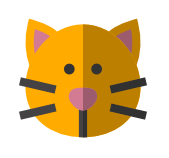

In [3]:
# 이미지 불러오기
cat = Image.open("../Data/cat.png")
cat

In [4]:
# Image 층(Layer) 확인
cat.getbands()

('R', 'G', 'B')

#### Modes
- L : black and white
- RGB : True Color
- RGBA : 투명도가 있는 True Color
- YCbCr : Video 

In [ ]:
# Mode 확인
cat.mode

'RGB'

In [6]:
# Size
cat.size

(169, 158)

In [7]:
# File Name
cat.filename

'../Data/cat.png'

In [8]:
# File Format
cat.format

'PNG'

In [9]:
# Convert to JPEG
cat.save("../Data/cat1.jpg")

#### Thumbnail 만들기
- 가로와 세로의 크기를 반으로 줄인다. 
- 반으로 줄이면 실수(Real Nunber)가 발생할 수 있어 소수점 이하 truncate

In [13]:
import math

In [14]:
math.trunc(cat.size[0] / 2)

84

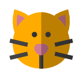

In [18]:
# Thumbnail 만들기
size = math.trunc(cat.size[0] / 2), math.trunc(cat.size[1] / 2)
carThumb = cat.copy()
carThumb.thumbnail(size)
carThumb.save("../Data/thumb.png")
carThumb

---
#### Image Manipulation

##### Image Crop

In [20]:
# 이미지 크기
print('전체크기 :', cat.size)
print('가로크기 :', cat.width)
print('세로크기 :', cat.height)

전체크기 : (169, 158)
가로크기 : 169
세로크기 : 158


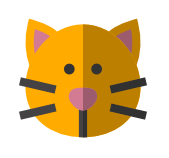

In [21]:
cat

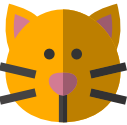

In [22]:
box = (20, 15, 147, 140) # x좌표, y좌표, x크기, y크기
catcrop = cat.crop(box)
catcrop

#### Image Rotation

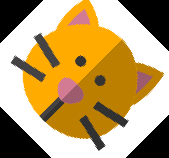

In [26]:
catRotate = cat.rotate(-45) # 각도
catRotate

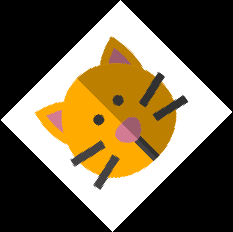

In [28]:
catRotate = cat.rotate(45, expand=True)
catRotate

#### Image Merge

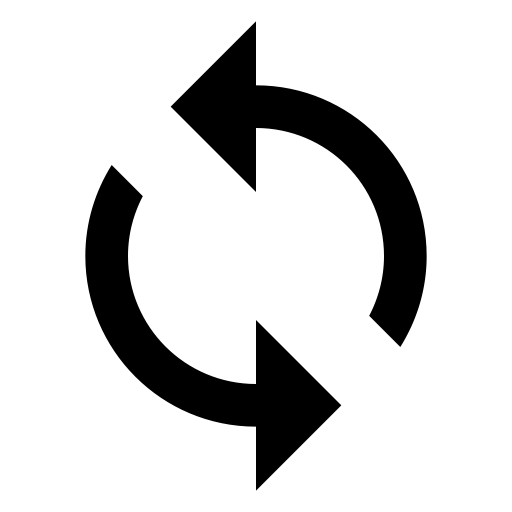

In [29]:
record = Image.open("../Data/record.png")
record

In [30]:
# mode 확인
record.mode

'RGBA'

In [31]:
# 크기 확인
record.size

(512, 512)

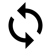

In [34]:
# 이미지 크기가 cat보다 커서 줄이자
# 1/10 크기로 줄여서 recordThumb를 만들자
size = math.trunc(record.width / 10), math.trunc(record.height / 10)
recordThumb = record.copy()
recordThumb.thumbnail(size)
recordThumb.save("../Data/record_thumb.png")
recordThumb

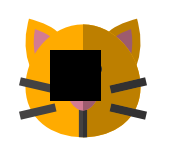

In [35]:
# cat(169, 158)위에 recordThumb를 배치
position = (50, 50)
catMerge = cat.copy()
catMerge.paste(recordThumb, position)
catMerge

> recordThumb의 배경색은 투명(검은색)이고 이미지도 검은색   
검은색 투명도 제거 

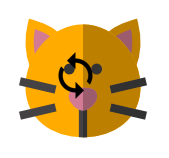

In [36]:
# cat(169, 158)위에 recordThumb를 배치
position = (50, 50)
catMerge = cat.copy()
catMerge.paste(recordThumb, position, recordThumb)
catMerge

#### Center에 배치

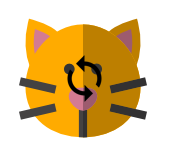

In [ ]:
# cat(169, 158)위에 recordThumb를 배치
position = (math.trunc((cat.width - recordThumb.width)/2), \
            math.trunc((cat.height - recordThumb.height)/2))
catMerge = cat.copy()
catMerge.paste(recordThumb, position, recordThumb)
catMerge

#### Image Flip

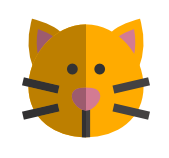

In [39]:
catFlip = cat.copy()
catFlip.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

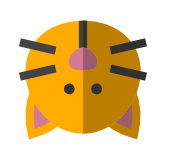

In [40]:
catFlip.transpose(Image.Transpose.FLIP_TOP_BOTTOM)

#### PIL image to Numpy array

In [41]:
import numpy as np

In [42]:
cat_array = np.array(cat)
cat_array

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [43]:
cat_array.shape

(158, 169, 3)

In [44]:
# Numpy array -> Image
img = Image.fromarray(cat_array, 'RGB')
img.save("../Data/cat_array.png")
img.show()

In [45]:
# 특정 pixel의 RGB 값 확인
cat.getpixel((70, 70))

(51, 51, 51)

#### Color Transformation

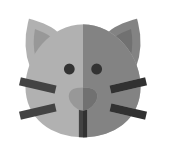

In [47]:
# RGB -> 흑백
cat.convert("L")

----
#### Image Enhacement

In [48]:
from PIL import ImageEnhance

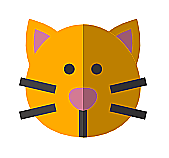

In [51]:
# image sharpness
enhance = ImageEnhance.Sharpness(cat)
enhance.enhance(5)

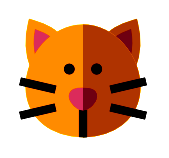

In [52]:
# image contrast
enhance = ImageEnhance.Contrast(cat)
enhance.enhance(2)

#### Filters

In [53]:
from PIL import ImageFilter

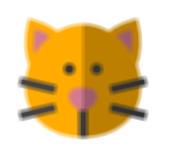

In [54]:
# Blur
cat.filter(ImageFilter.BLUR)

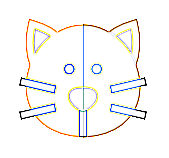

In [55]:
# Contour
cat.filter(ImageFilter.CONTOUR)

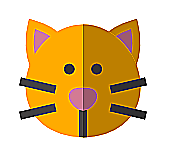

In [56]:
# Edge Enhance
cat.filter(ImageFilter.EDGE_ENHANCE)

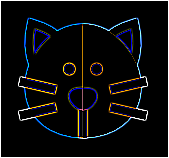

In [57]:
# Find Edge
cat.filter(ImageFilter.FIND_EDGES)

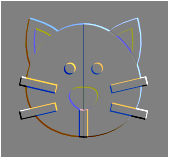

In [58]:
# Emboss
cat.filter(ImageFilter.EMBOSS)

----
#### Augmented Image 증강(유사 이미지 증강)

In [59]:
from PIL import Image

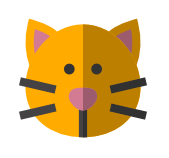

In [60]:
img = Image.open("../Data/cat.png")
img

In [62]:
# 회전 데이터 추가
counter = 0

for angle in range(-15, 15, 1):
    counter+=1
    img2 = img.rotate(angle)
    img2.save(f"../Data/Cat/rotation_{counter}.png")
    
	# 반전 데이터 추가
    img3 = img2.transpose(Image.FLIP_LEFT_RIGHT)
    img3.save(f"../Data/Cat/flip_{counter}.png")
    

In [65]:
import numpy as np
list(np.arange(1, 10, 0.5))

[np.float64(1.0),
 np.float64(1.5),
 np.float64(2.0),
 np.float64(2.5),
 np.float64(3.0),
 np.float64(3.5),
 np.float64(4.0),
 np.float64(4.5),
 np.float64(5.0),
 np.float64(5.5),
 np.float64(6.0),
 np.float64(6.5),
 np.float64(7.0),
 np.float64(7.5),
 np.float64(8.0),
 np.float64(8.5),
 np.float64(9.0),
 np.float64(9.5)]

In [66]:
import numpy as np

for angle in np.arange(-15, 15, 0.5):
    counter+=1
    img2 = img.rotate(angle)
    img2.save(f"../Data/Cat/rotation_{counter}.png")
    
	# 반전 데이터 추가
    img3 = img2.transpose(Image.FLIP_LEFT_RIGHT)
    img3.save(f"../Data/Cat/flip_{counter}.png")
